In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# Config
# =========================
FOLDERS = ["100-250", "100-300", "100-350", "100-400", "100-450", "100-500",
           "120-300", "120-350", "120-400", "120-450", "120-500",
           "140-350", "140-400", "140-450", "140-500"]

CHANNEL = "ch0"
CONDITIONS = ["arrhy", "rhy"]
METRICS = {
    "neuronal": "trial_acc_neuronal",
    "synaptic": "trial_acc_synaptic",
}

def find_root():
    cwd = Path.cwd()
    if (cwd / "decoder_plv.py").exists():
        return cwd
    if (cwd / "decode_stsp" / "decoder_plv.py").exists():
        return cwd / "decode_stsp"
    raise FileNotFoundError("Cannot find decode_stsp root.")

ROOT = find_root()
print("ROOT =", ROOT)


# =========================
# Helpers
# =========================
def load_result(folder, condition, channel):
    path = ROOT / folder / "results_by_PLV_bin" / f"{condition}_{channel}_PLV_binned_results.npz"
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    return np.load(path, allow_pickle=True)


def window_acc_onset_to_5ioi_sd(trial_acc, sample_onsets, ioi_steps, sd_steps):
    n_trials, n_time, n_items = trial_acc.shape
    out = np.full((n_trials, n_items), np.nan, dtype=float)
    window_len = int(ioi_steps*5 + sd_steps)

    for trial in range(n_trials):
        for item in range(n_items):
            start = int(sample_onsets[trial, item]+50)
            end = int(start + window_len)

            start_clip = max(0, start)
            end_clip = min(n_time, end)

            if end_clip > start_clip:
                out[trial, item] = np.nanmean(
                    trial_acc[trial, start_clip:end_clip, item]
                )

    return out


def build_plv_acc_dataframe(folders, channel, conditions):
    rows = []

    for folder in folders:
        for condition in conditions:
            data = load_result(folder, condition, channel)

            plv = data["plv_values"]          # trial x item
            sample_onsets = data["sample_onsets"]
            ioi_steps = int(np.asarray(data["ioi_steps"]).squeeze())
            sd_steps = int(np.asarray(data["sd_steps"]).squeeze())

            for metric, trial_acc_key in METRICS.items():
                trial_acc = data[trial_acc_key]

                window_acc = window_acc_onset_to_5ioi_sd(
                    trial_acc,
                    sample_onsets,
                    ioi_steps=ioi_steps,
                    sd_steps=sd_steps,
                )

                n_trials, n_items = plv.shape

                for trial in range(n_trials):
                    for item in range(n_items):
                        rows.append({
                            "folder": folder,
                            "condition": condition,
                            "metric": metric,
                            "trial": trial,
                            "item": item + 1,
                            "plv": plv[trial, item],
                            "acc": window_acc[trial, item],
                        })

    return pd.DataFrame(rows)


def corr_one_group(df):
    x = df["plv"].to_numpy(dtype=float)
    y = df["acc"].to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {
            "n": len(x),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_p": np.nan,
            "slope": np.nan,
            "intercept": np.nan,
            "linear_p": np.nan,
        }

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    lr = stats.linregress(x, y)

    return {
        "n": len(x),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "slope": lr.slope,
        "intercept": lr.intercept,
        "linear_p": lr.pvalue,
    }


# =========================
# Build data
# =========================
df = build_plv_acc_dataframe(
    FOLDERS,
    CHANNEL,
    CONDITIONS,
)

# display(df.head())


# =========================
# Correlation stats: condition x metric x item
# =========================
rows = []

for condition in CONDITIONS:
    for metric in METRICS.keys():
        for item in range(1, 7):
            sub = df[
                (df["condition"] == condition)
                & (df["metric"] == metric)
                & (df["item"] == item)
            ]

            res = corr_one_group(sub)
            res.update({
                "condition": condition,
                "metric": metric,
                "item": item,
            })
            rows.append(res)

        # pooled across items
        sub = df[
            (df["condition"] == condition)
            & (df["metric"] == metric)
        ]

        res = corr_one_group(sub)
        res.update({
            "condition": condition,
            "metric": metric,
            "item": "all",
        })
        rows.append(res)

corr_df = pd.DataFrame(rows)

corr_df = corr_df[
    [
        "condition",
        "metric",
        "item",
        "n",
        "pearson_r",
        "pearson_p",
        "spearman_r",
        "spearman_p",
        "slope",
        "intercept",
        "linear_p",
    ]
]

# display(corr_df)

ROOT = e:\code_project\rhythmic_working_memory\decode_stsp


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

METRIC_COLORS = {
    "neuronal": "#4DB6AC",
    "synaptic": "#FF8A65",
}

def plot_overall_neu_syn_together(
    df,
    items=(1, 2, 3, 4, 5, 6),
    folders=None,
    n_bins=8,
    plv_range=(0.80, 1.00),
    min_count_per_bin=5,
    use_bin_center=True,
    show_errorbar=True,
):

    sub = df.copy()

    sub = sub[sub["item"].isin(items)].copy()

    if folders is not None and "folder" in sub.columns:
        sub = sub[sub["folder"].isin(folders)].copy()

    sub = sub[np.isfinite(sub["plv"]) & np.isfinite(sub["acc"])].copy()

    sub = sub[sub["metric"].isin(["neuronal", "synaptic"])].copy()

    if plv_range is None:
        plv_min = float(np.nanmin(sub["plv"]))
        plv_max = float(np.nanmax(sub["plv"]))
    else:
        plv_min, plv_max = plv_range

    if plv_min >= plv_max:
        raise ValueError(f" plv_range: {plv_range}")

    bin_edges = np.linspace(plv_min, plv_max, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    sub["plv_bin"] = pd.cut(
        sub["plv"],
        bins=bin_edges,
        labels=False,
        include_lowest=True,
        right=True,
    )

    sub = sub[np.isfinite(sub["plv_bin"])].copy()
    sub["plv_bin"] = sub["plv_bin"].astype(int)
    sub["plv_bin_center"] = sub["plv_bin"].map(
        {i: bin_centers[i] for i in range(len(bin_centers))}
    )

    x_col = "plv_bin_center" if use_bin_center else "plv"

    fig, ax = plt.subplots(figsize=(5.8, 4.6))

    text_y_map = {
        "neuronal": 0.45,
        "synaptic": 0.25,
    }

    summary_dict = {}

    for metric in ["neuronal", "synaptic"]:
        sm = sub[sub["metric"] == metric].copy()
        if len(sm) == 0:
            continue

        curve = (
            sm
            .groupby("plv_bin", as_index=False)
            .agg(
                plv_center=("plv_bin_center", "mean"),
                plv_mean=("plv", "mean"),
                acc_mean=("acc", "mean"),
                acc_sem=("acc", lambda x: stats.sem(x, nan_policy="omit") if len(x) > 1 else np.nan),
                n=("acc", "count"),
            )
            .sort_values("plv_bin")
        )

        curve = curve[curve["n"] >= min_count_per_bin].copy()

        metric_color = METRIC_COLORS.get(metric, "black")

        if show_errorbar:
            ax.errorbar(
                curve["plv_center"],
                curve["acc_mean"],
                yerr=curve["acc_sem"],
                marker="o",
                linewidth=2.2,
                markersize=5.2,
                capsize=3,
                color=metric_color,
                label=metric,
            )
        else:
            ax.plot(
                curve["plv_center"],
                curve["acc_mean"],
                marker="o",
                linewidth=2.2,
                markersize=5.2,
                color=metric_color,
                label=metric,
            )

        valid_curve = np.isfinite(curve["plv_center"]) & np.isfinite(curve["acc_mean"])
        if np.sum(valid_curve) >= 3:
            lr = stats.linregress(
                curve.loc[valid_curve, "plv_center"],
                curve.loc[valid_curve, "acc_mean"]
            )

            xfit = np.linspace(curve["plv_center"].min(), curve["plv_center"].max(), 200)
            yfit = lr.intercept + lr.slope * xfit

            ax.plot(
                xfit,
                yfit,
                linestyle="--",
                linewidth=1.4,
                color=metric_color,
                alpha=0.65,
            )
        else:
            lr = None

        x_raw = sm["plv"].to_numpy(dtype=float)
        y_raw = sm["acc"].to_numpy(dtype=float)
        valid_raw = np.isfinite(x_raw) & np.isfinite(y_raw)
        x_raw = x_raw[valid_raw]
        y_raw = y_raw[valid_raw]

        if len(x_raw) >= 5 and len(np.unique(x_raw)) > 1 and len(np.unique(y_raw)) > 1:
            sp_r, sp_p = stats.spearmanr(x_raw, y_raw)
            pe_r, pe_p = stats.pearsonr(x_raw, y_raw)
        else:
            sp_r, sp_p = np.nan, np.nan
            pe_r, pe_p = np.nan, np.nan

        summary_dict[metric] = {
            "n_raw": len(x_raw),
            "spearman_r": sp_r,
            "spearman_p": sp_p,
            "pearson_r": pe_r,
            "pearson_p": pe_p,
            "slope": np.nan if lr is None else lr.slope,
            "slope_p": np.nan if lr is None else lr.pvalue,
        }

        text_y = text_y_map.get(metric, 0.9)
        text = (
            f"{metric}\n"
            f"Spearman ρ = {sp_r:.3f}, p = {sp_p:.2g}\n"
            f"Pearson r = {pe_r:.3f}, p = {pe_p:.2g}\n"
            f"slope = {np.nan if lr is None else lr.slope:.3f}"
        )

        ax.text(
            0.04,
            text_y,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            color="black",
        )

    ax.set_xlabel("PLV")
    ax.set_ylabel("Decoding accuracy")
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    ax.set_ylim(0.0, 1.0)

    ax.set_title(f"PLV-binned decoding accuracy analysis")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc="lower right")

    fig.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_dict).T.reset_index().rename(columns={"index": "metric"})
    print("Summary:")
    display(summary_df)

    fig.savefig(f"PLV-binned decoding accuracy analysis.pdf", format="pdf", dpi=300, bbox_inches="tight")

    return summary_df

Fig5A


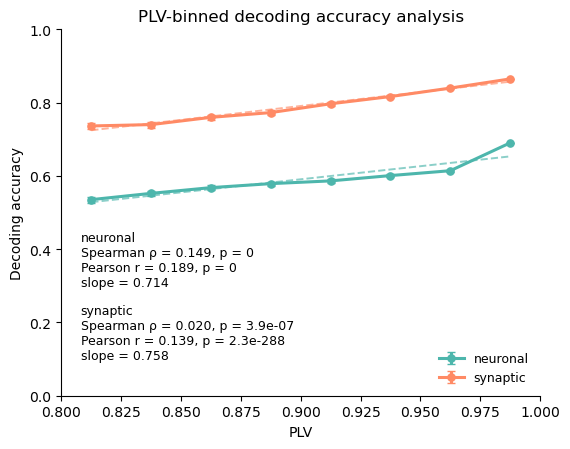

Summary:


,metric,n_raw,spearman_r,spearman_p,pearson_r,pearson_p,slope,slope_p
0,neuronal,67592.0,0.148967,0.000000e+00,0.188916,0.000000e+00,0.714120,0.001141
1,synaptic,67592.0,0.019515,3.894179e-07,0.138912,2.294759e-288,0.757779,0.000003


In [6]:
summary_df = plot_overall_neu_syn_together(
    df,
    items=(1, 2, 3, 4, 5, 6),
    folders=None,
    n_bins=8,
    plv_range=(0.80, 1.00),
    min_count_per_bin=5,
    use_bin_center=True,
    show_errorbar=True,
)